Saving input.jpg to input.jpg
Image loaded successfully: input.jpg
Image shape: (3301, 2322, 3)


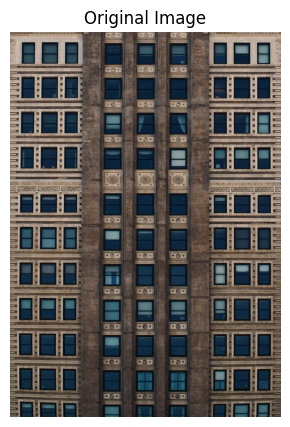

In [1]:
# Experiment No. 5
# Feature Extraction and Image Analysis using SIFT and HOG Descriptors

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
import time
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]
img = cv2.imread(image_path)

if img is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully:", image_path)
    print("Image shape:", img.shape)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

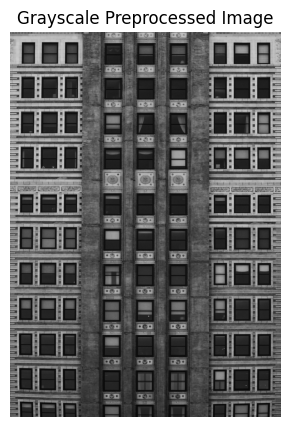

In [2]:
# Step 2: Convert image to grayscale and perform preprocessing

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Mild Gaussian blur for noise reduction
gray = cv2.GaussianBlur(gray, (3, 3), 0)

plt.figure(figsize=(7, 5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Preprocessed Image")
plt.axis("off")
plt.show()

In [3]:
# Step 3: Apply SIFT to detect keypoints and compute descriptors

sift = cv2.SIFT_create()

t0 = time.perf_counter()

keypoints, descriptors = sift.detectAndCompute(gray, None)

t_sift = time.perf_counter() - t0

print("SIFT Feature Extraction")
print("------------------------")
print("Number of keypoints detected:", len(keypoints))
print("Descriptor shape:",
      descriptors.shape if descriptors is not None else None)
print(f"Time taken: {t_sift:.4f} seconds")

SIFT Feature Extraction
------------------------
Number of keypoints detected: 32479
Descriptor shape: (32479, 128)
Time taken: 4.2398 seconds


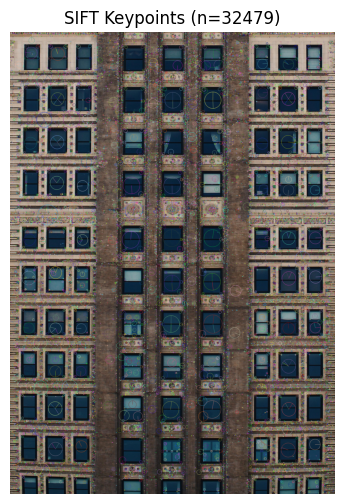

Keypoint spread - X: [2.4, 2319.0]
Keypoint spread - Y: [2.4, 3298.0]


In [4]:
# Step 4: Visualize SIFT keypoints

img_keypoints = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(img_keypoints, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Keypoints (n={len(keypoints)})")
plt.axis("off")
plt.show()

if keypoints:
    xs = [kp.pt[0] for kp in keypoints]
    ys = [kp.pt[1] for kp in keypoints]

    print(f"Keypoint spread - X: [{min(xs):.1f}, {max(xs):.1f}]")
    print(f"Keypoint spread - Y: [{min(ys):.1f}, {max(ys):.1f}]")

In [5]:
# Step 5: Extract HOG features

hog_resized = cv2.resize(gray, (128, 128))

t0 = time.perf_counter()

hog_features, hog_image = hog(
    hog_resized,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

t_hog = time.perf_counter() - t0

print("HOG Feature Extraction")
print("----------------------")
print("HOG feature vector length:", hog_features.shape[0])
print(f"Time taken: {t_hog:.4f} seconds")

HOG Feature Extraction
----------------------
HOG feature vector length: 8100
Time taken: 0.1865 seconds


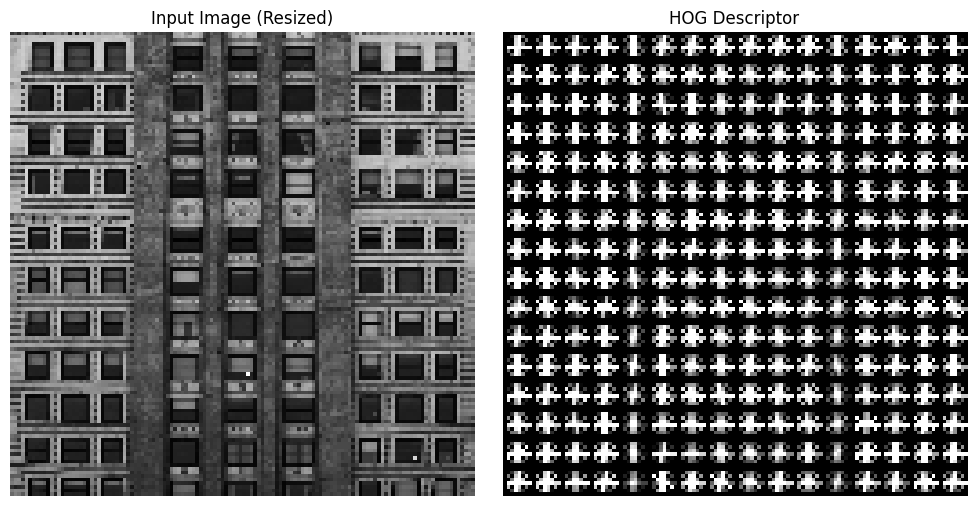

In [6]:
# Step 6: Visualize HOG descriptor

hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(0, 10)
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(hog_resized, cmap="gray")
plt.title("Input Image (Resized)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image_rescaled, cmap="gray")
plt.title("HOG Descriptor")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Step 7: Compare SIFT and HOG characteristics

print("SIFT vs HOG Comparison")
print("----------------------")

print(f"{'Property':25s} | {'SIFT':30s} | {'HOG':30s}")
print("-" * 95)

print(f"{'Type':25s} | {'Sparse keypoints + descriptor':30s} | {'Dense feature descriptor':30s}")

print(f"{'Scale invariance':25s} | {'Yes':30s} | {'No':30s}")

print(f"{'Rotation invariance':25s} | {'Yes':30s} | {'No':30s}")

print(f"{'Output size':25s} | {f'{len(keypoints)} x 128':30s} | {f'{hog_features.shape[0]} values':30s}")

print(f"{'Compute time (s)':25s} | {t_sift:<30.4f} | {t_hog:<30.4f}")

SIFT vs HOG Comparison
----------------------
Property                  | SIFT                           | HOG                           
-----------------------------------------------------------------------------------------------
Type                      | Sparse keypoints + descriptor  | Dense feature descriptor      
Scale invariance          | Yes                            | No                            
Rotation invariance       | Yes                            | No                            
Output size               | 32479 x 128                    | 8100 values                   
Compute time (s)          | 4.2398                         | 0.1865                        


Image 2 keypoints: 30163
Total matches found: 20893
Best match distance: 14.63


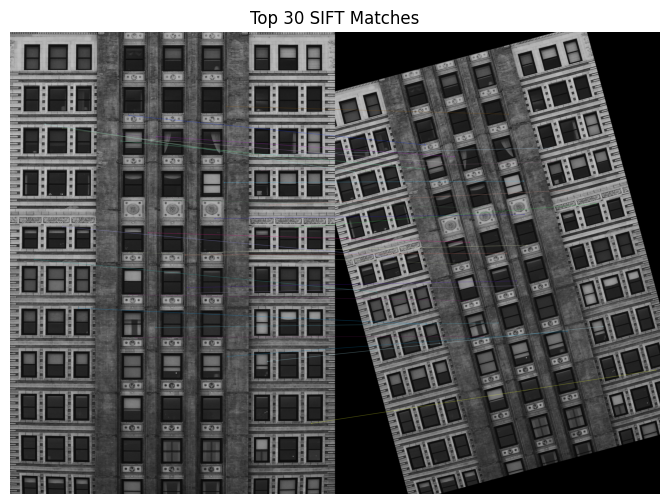

In [10]:
# Step 8: Image matching using SIFT
# Create a similar image by rotating and scaling the original

center = (gray.shape[1] // 2, gray.shape[0] // 2)

rotation_matrix = cv2.getRotationMatrix2D(
    center,
    15,
    0.9
)

gray2 = cv2.warpAffine(
    gray,
    rotation_matrix,
    (gray.shape[1], gray.shape[0])
)

kp2, des2 = sift.detectAndCompute(gray2, None)

print("Image 2 keypoints:", len(kp2))

if descriptors is not None and des2 is not None:

    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

    matches = bf.match(descriptors, des2)

    matches = sorted(
        matches,
        key=lambda m: m.distance
    )

    print("Total matches found:", len(matches))

    if matches:
        print(f"Best match distance: {matches[0].distance:.2f}")

    match_img = cv2.drawMatches(
        gray,
        keypoints,
        gray2,
        kp2,
        matches[:30],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(14, 6))
    plt.imshow(match_img, cmap="gray")
    plt.title("Top 30 SIFT Matches")
    plt.axis("off")
    plt.show()

else:
    print("SIFT descriptors could not be generated.")

In [11]:
# Step 9: Evaluate strengths and limitations

if descriptors is not None and des2 is not None and len(matches) > 0:

    good_matches = [
        m for m in matches
        if m.distance < 200
    ]

    print("SIFT Matching Evaluation")
    print("------------------------")
    print("Total matches:", len(matches))
    print("Good matches (distance < 200):",
          len(good_matches))

print("\nSIFT Strengths:")
print("- Scale invariant")
print("- Rotation invariant")
print("- Robust to moderate illumination changes")
print("- Useful for image matching and object recognition")

print("\nSIFT Limitations:")
print("- Computationally more expensive")
print("- Produces many keypoints")
print("- Can be slower for large images")

print("\nHOG Strengths:")
print("- Captures shape and edge information")
print("- Simple and interpretable")
print("- Useful for object detection")

print("\nHOG Limitations:")
print("- Not inherently scale invariant")
print("- Not inherently rotation invariant")
print("- Works best with fixed-size images")

SIFT Matching Evaluation
------------------------
Total matches: 20893
Good matches (distance < 200): 20671

SIFT Strengths:
- Scale invariant
- Rotation invariant
- Robust to moderate illumination changes
- Useful for image matching and object recognition

SIFT Limitations:
- Computationally more expensive
- Produces many keypoints
- Can be slower for large images

HOG Strengths:
- Captures shape and edge information
- Simple and interpretable
- Useful for object detection

HOG Limitations:
- Not inherently scale invariant
- Not inherently rotation invariant
- Works best with fixed-size images


In [12]:
# Step 10: Document observations and applications

print("OBSERVATIONS")
print("------------")

print("1. SIFT detected distinctive keypoints from the building image.")
print("2. Most keypoints were concentrated around corners, windows, edges, and textured regions.")
print("3. SIFT descriptors are robust to rotation and scale changes.")
print("4. HOG captured the gradient and edge patterns present in the image.")
print("5. HOG is useful for describing overall shape and structural information.")
print("6. SIFT is suitable for image matching and object recognition.")
print("7. HOG is suitable for traditional object detection tasks.")
print("8. SIFT is generally more computationally expensive than HOG.")

print("\nAPPLICATIONS")
print("------------")
print("SIFT:")
print("- Image matching")
print("- Object recognition")
print("- Panorama stitching")
print("- Logo recognition")
print("- 3D reconstruction")

print("\nHOG:")
print("- Pedestrian detection")
print("- Human detection")
print("- Vehicle detection")
print("- Object detection using HOG + SVM")

OBSERVATIONS
------------
1. SIFT detected distinctive keypoints from the building image.
2. Most keypoints were concentrated around corners, windows, edges, and textured regions.
3. SIFT descriptors are robust to rotation and scale changes.
4. HOG captured the gradient and edge patterns present in the image.
5. HOG is useful for describing overall shape and structural information.
6. SIFT is suitable for image matching and object recognition.
7. HOG is suitable for traditional object detection tasks.
8. SIFT is generally more computationally expensive than HOG.

APPLICATIONS
------------
SIFT:
- Image matching
- Object recognition
- Panorama stitching
- Logo recognition
- 3D reconstruction

HOG:
- Pedestrian detection
- Human detection
- Vehicle detection
- Object detection using HOG + SVM
